In [3]:
library(readxl)
library(dplyr)
library(ggplot2)
library(cluster)
library(factoextra)
library(scales)
library(tidyr)

In [4]:
# 1. LOAD DATA
# ============================================================
 
transactions <- read_excel(
  "/kaggle/input/datasets/mickey2003/online-retail/Online Retail.xlsx"
)
 
# Standardise column names (remove spaces if any)
colnames(transactions) <- trimws(colnames(transactions))
 
# Parse date and compute revenue
transactions <- transactions %>%
  mutate(
    InvoiceDate = as.Date(InvoiceDate),
    Revenue     = Quantity * UnitPrice
  )
 
cat("Records loaded     :", nrow(transactions), "\n")
cat("Unique customers   :", n_distinct(transactions$CustomerID), "\n")
cat("Date range         :", as.character(min(transactions$InvoiceDate, na.rm = TRUE)),
    "to", as.character(max(transactions$InvoiceDate, na.rm = TRUE)), "\n\n")

Records loaded     : 541909 
Unique customers   : 4373 
Date range         : 2010-12-01 to 2011-12-09 



In [5]:
# 2. DATA QUALITY VALIDATION
# ============================================================
 
cat("--- Data Quality Report ---\n")
cat("Missing CustomerID :", sum(is.na(transactions$CustomerID)), "\n")
cat("Negative Quantity  :", sum(transactions$Quantity  < 0, na.rm = TRUE), "\n")
cat("Zero UnitPrice     :", sum(transactions$UnitPrice == 0, na.rm = TRUE), "\n")
cat("Cancelled orders   :", sum(grepl("^C", transactions$InvoiceNo)), "\n\n")
 
transactions_clean <- transactions %>%
  filter(
    !is.na(CustomerID),
    Quantity  > 0,
    UnitPrice > 0,
    !grepl("^C", InvoiceNo)   # remove cancellations
  )
 
cat("Records after cleaning:", nrow(transactions_clean),
    sprintf("(%.1f%% retained)\n\n",
            100 * nrow(transactions_clean) / nrow(transactions)))

--- Data Quality Report ---
Missing CustomerID : 135080 
Negative Quantity  : 10624 
Zero UnitPrice     : 2515 
Cancelled orders   : 9288 

Records after cleaning: 397884 (73.4% retained)



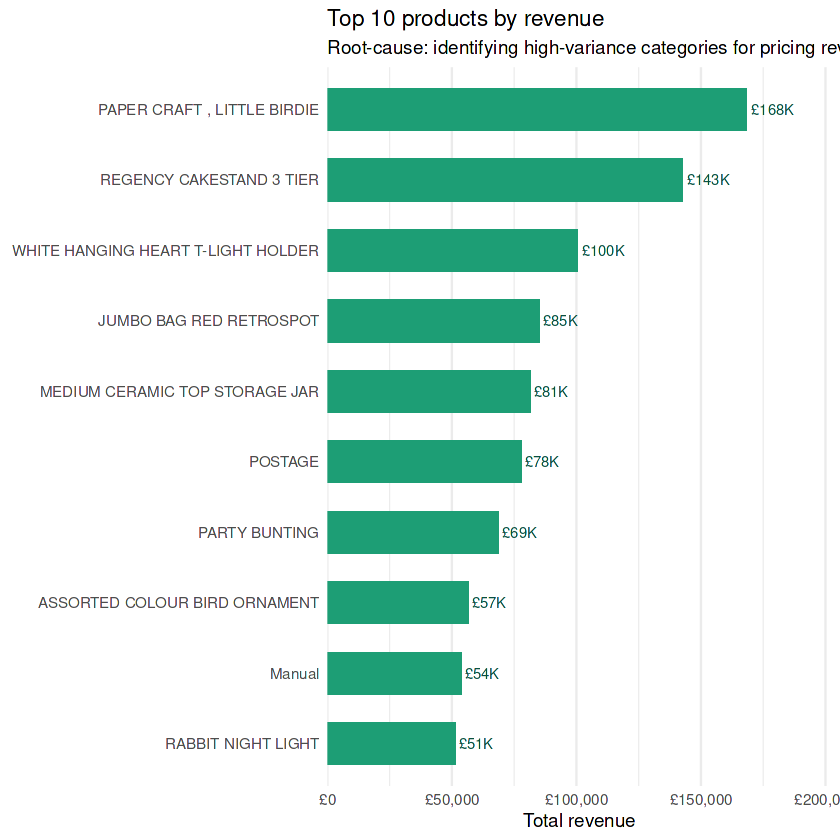

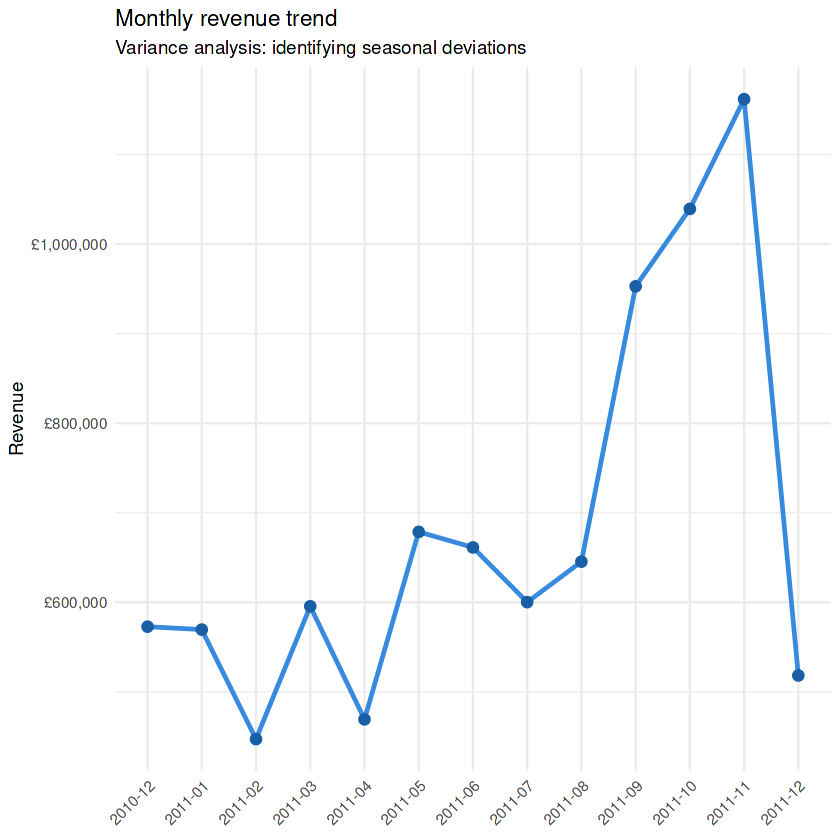

In [6]:
# 3. EDA — REVENUE VARIANCE ANALYSIS
# ============================================================
 
category_revenue <- transactions_clean %>%
  group_by(Description) %>%
  summarise(
    total_revenue = sum(Revenue),
    orders        = n_distinct(InvoiceNo),
    .groups       = "drop"
  ) %>%
  arrange(desc(total_revenue)) %>%
  slice(1:10)   # top 10 for readability
 
p1 <- ggplot(category_revenue,
             aes(x = reorder(Description, total_revenue), y = total_revenue)) +
  geom_col(fill = "#1D9E75", width = 0.6) +
  geom_text(aes(label = paste0("£", round(total_revenue / 1000), "K")),
            hjust = -0.1, size = 3, color = "#085041") +
  coord_flip() +
  scale_y_continuous(labels   = label_comma(prefix = "£"),
                     expand   = expansion(mult = c(0, 0.2))) +
  labs(title    = "Top 10 products by revenue",
       subtitle = "Root-cause: identifying high-variance categories for pricing review",
       x = NULL, y = "Total revenue") +
  theme_minimal(base_size = 11) +
  theme(panel.grid.major.y = element_blank())
 
print(p1)
 
# Monthly revenue trend
monthly <- transactions_clean %>%
  mutate(month = format(InvoiceDate, "%Y-%m")) %>%
  group_by(month) %>%
  summarise(revenue = sum(Revenue), .groups = "drop") %>%
  arrange(month)
 
p2 <- ggplot(monthly, aes(x = month, y = revenue, group = 1)) +
  geom_line(color = "#378ADD", linewidth = 1) +
  geom_point(color = "#185FA5", size = 2.5) +
  scale_y_continuous(labels = label_comma(prefix = "£")) +
  labs(title    = "Monthly revenue trend",
       subtitle = "Variance analysis: identifying seasonal deviations",
       x = NULL, y = "Revenue") +
  theme_minimal(base_size = 11) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))
 
print(p2)

--- RFM Feature Summary ---
    Recency         Frequency          Monetary        
 Min.   :  1.00   Min.   :  1.000   Min.   :     3.75  
 1st Qu.: 18.00   1st Qu.:  1.000   1st Qu.:   307.42  
 Median : 51.00   Median :  2.000   Median :   674.48  
 Mean   : 93.06   Mean   :  4.272   Mean   :  2054.27  
 3rd Qu.:142.75   3rd Qu.:  5.000   3rd Qu.:  1661.74  
 Max.   :374.00   Max.   :209.000   Max.   :280206.02  



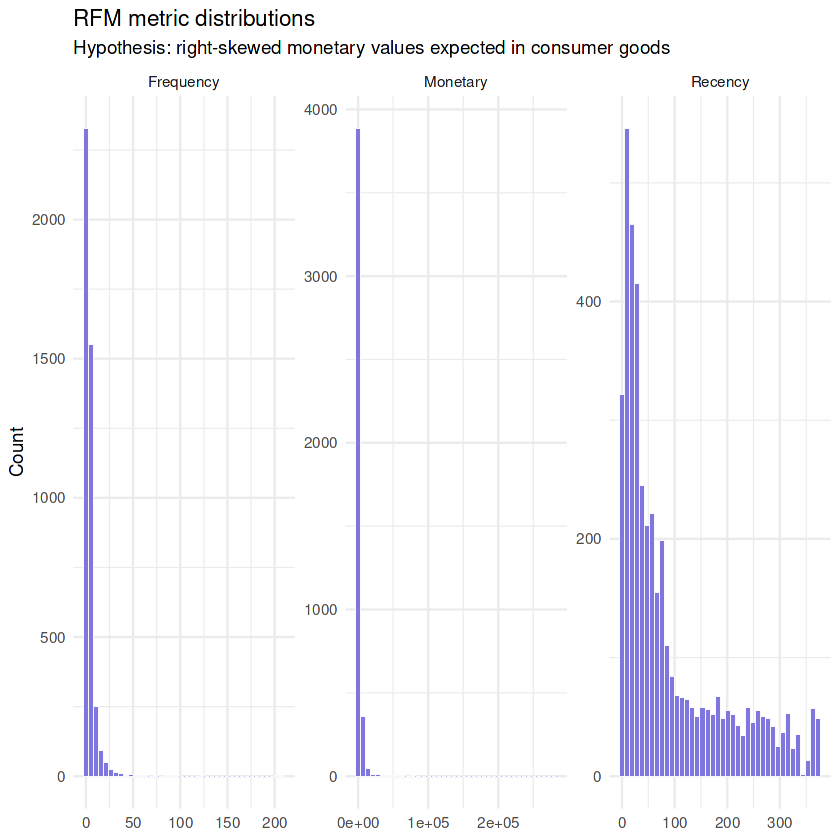

In [7]:
# ============================================================
# 4. RFM FEATURE ENGINEERING
# ============================================================
 
snapshot_date <- max(transactions_clean$InvoiceDate, na.rm = TRUE) + 1
 
rfm <- transactions_clean %>%
  group_by(CustomerID) %>%
  summarise(
    Recency   = as.numeric(snapshot_date - max(InvoiceDate)),
    Frequency = n_distinct(InvoiceNo),
    Monetary  = sum(Revenue),
    .groups   = "drop"
  ) %>%
  mutate(
    R_score   = ntile(-Recency,  5),
    F_score   = ntile(Frequency, 5),
    M_score   = ntile(Monetary,  5),
    RFM_score = R_score + F_score + M_score
  )
 
cat("--- RFM Feature Summary ---\n")
print(summary(rfm[, c("Recency","Frequency","Monetary")]))
cat("\n")
 
rfm_long <- rfm %>%
  select(Recency, Frequency, Monetary) %>%
  pivot_longer(everything(), names_to = "metric", values_to = "value")
 
p3 <- ggplot(rfm_long, aes(x = value)) +
  geom_histogram(bins = 40, fill = "#7F77DD", color = "white", linewidth = 0.2) +
  facet_wrap(~metric, scales = "free") +
  labs(title    = "RFM metric distributions",
       subtitle = "Hypothesis: right-skewed monetary values expected in consumer goods",
       x = NULL, y = "Count") +
  theme_minimal(base_size = 11)
 
print(p3)

Running Elbow Method...


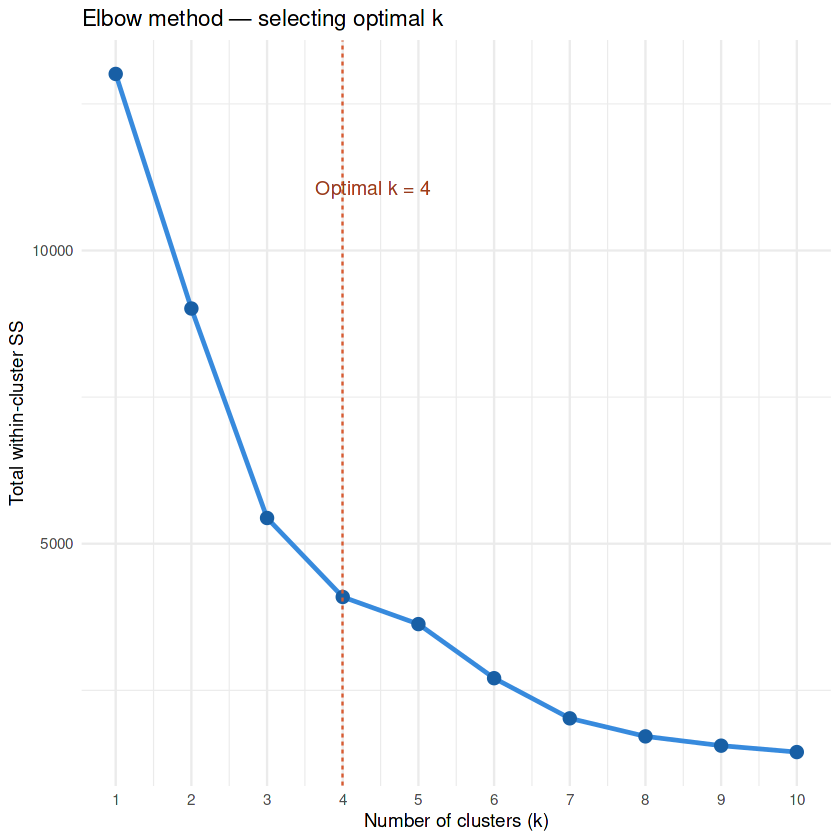

In [8]:
# ============================================================
# 5. PREDICTIVE MODELING — K-MEANS CLUSTERING
# ============================================================
 
rfm_scaled <- scale(rfm[, c("Recency","Frequency","Monetary")])
 
# -- 5a. Elbow Method ----------------------------------------
cat("Running Elbow Method...\n")
 
set.seed(42)
wss <- sapply(1:10, function(k) {
  kmeans(rfm_scaled, centers = k, nstart = 25, iter.max = 100)$tot.withinss
})
 
elbow_df <- data.frame(k = 1:10, wss = wss)
 
p4 <- ggplot(elbow_df, aes(x = k, y = wss)) +
  geom_line(color = "#378ADD", linewidth = 1) +
  geom_point(color = "#185FA5", size = 3) +
  geom_vline(xintercept = 4, linetype = "dashed", color = "#D85A30") +
  annotate("text", x = 4.4, y = max(wss) * 0.85,
           label = "Optimal k = 4", color = "#993C1D", size = 4) +
  scale_x_continuous(breaks = 1:10) +
  labs(title = "Elbow method — selecting optimal k",
       x = "Number of clusters (k)", y = "Total within-cluster SS") +
  theme_minimal(base_size = 11)
 
print(p4)

Running Silhouette Score...
Silhouette scores:
  k silhouette
1 2     0.8958
2 3     0.5937
3 4     0.6162
4 5     0.5014
5 6     0.5147
6 7     0.5215
7 8     0.4770
Best k: 2 

Cluster sizes:

   1    2    3    4 
1061 3055   13  209 



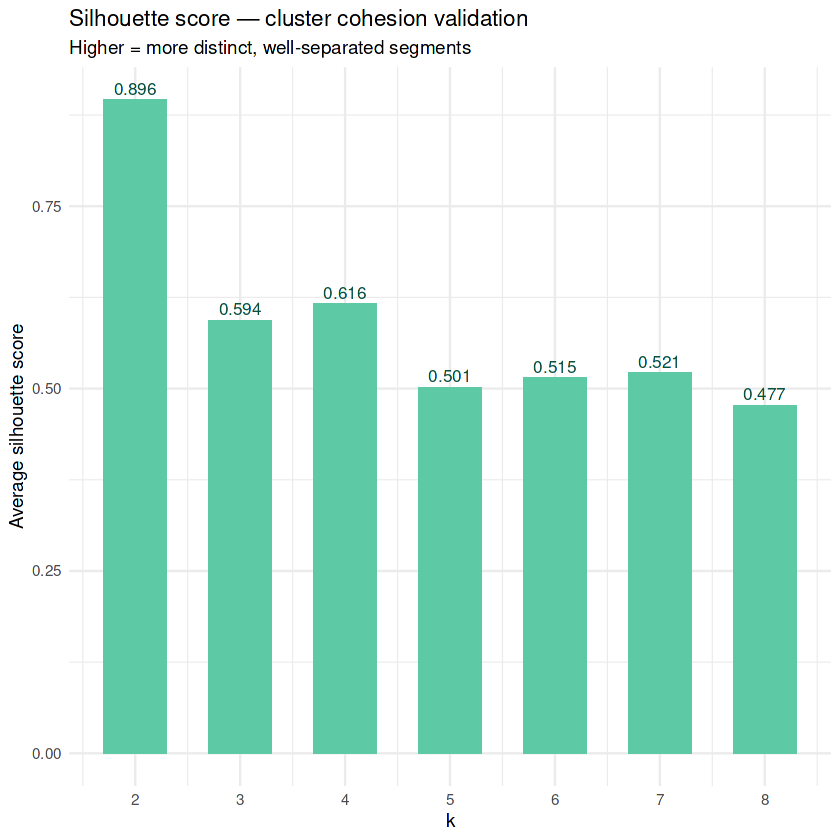

In [9]:
# -- 5b. Silhouette Score ------------------------------------
cat("Running Silhouette Score...\n")
 
set.seed(42)
sil_scores <- sapply(2:8, function(k) {
  km  <- kmeans(rfm_scaled, centers = k, nstart = 25)
  sil <- silhouette(km$cluster, dist(rfm_scaled))
  mean(sil[, 3])
})
 
sil_df <- data.frame(k = 2:8, silhouette = round(sil_scores, 4))
cat("Silhouette scores:\n")
print(sil_df)
cat("Best k:", sil_df$k[which.max(sil_df$silhouette)], "\n\n")
 
p5 <- ggplot(sil_df, aes(x = k, y = silhouette)) +
  geom_col(fill = "#5DCAA5", width = 0.6) +
  geom_text(aes(label = round(silhouette, 3)),
            vjust = -0.4, size = 3.5, color = "#085041") +
  scale_x_continuous(breaks = 2:8) +
  labs(title    = "Silhouette score — cluster cohesion validation",
       subtitle = "Higher = more distinct, well-separated segments",
       x = "k", y = "Average silhouette score") +
  theme_minimal(base_size = 11)
 
print(p5)
 
# -- 5c. Final model: k = 4 ----------------------------------
set.seed(42)
km_final    <- kmeans(rfm_scaled, centers = 4, nstart = 50, iter.max = 200)
rfm$Segment <- as.factor(km_final$cluster)
 
cat("Cluster sizes:\n")
print(table(rfm$Segment))
cat("\n")

--- Segment Profile & Brand Equity ---
# A tibble: 4 × 8
  Segment segment_label n_customers avg_recency avg_frequency avg_monetary
  <fct>   <chr>               <int>       <dbl>         <dbl>        <dbl>
1 2       At Risk              3055          44           3.7         1353
2 4       Champions             209          16          22.1        12510
3 3       Champions              13           8          82.5       127338
4 1       Lapsed               1061         249           1.6          478
# ℹ 2 more variables: revenue_share <dbl>, brand_affinity <chr>

Top 2 segments account for 75.7% of revenue
Insight: prioritise Champions + Loyal-High Value for retention investment



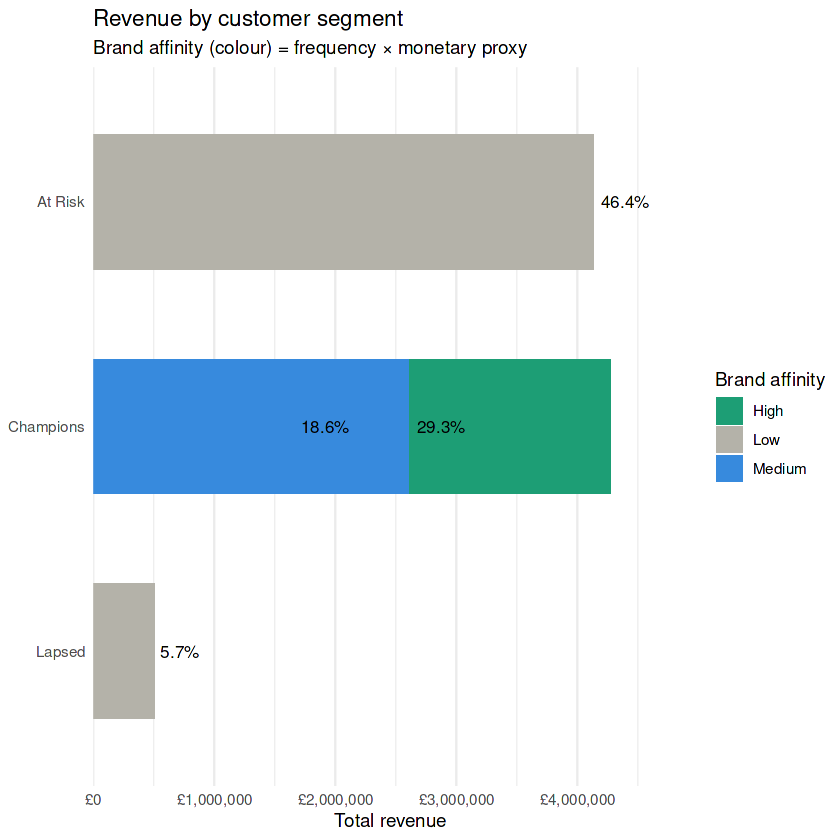

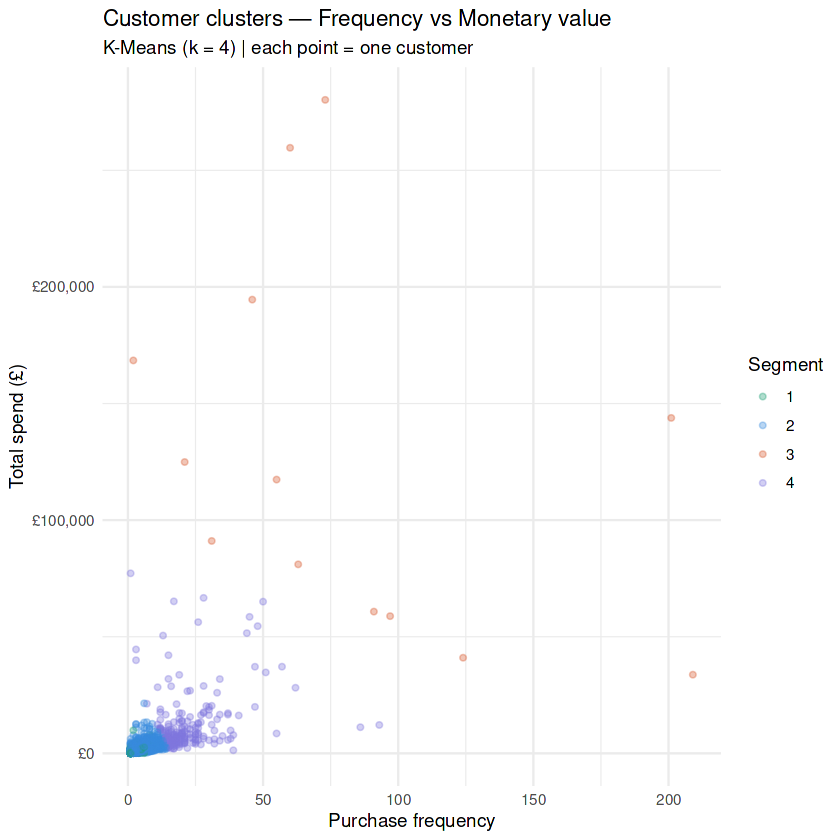

In [10]:
# 6. SEGMENT PROFILING & BRAND EQUITY ANALYSIS
# ============================================================
 
segment_profile <- rfm %>%
  group_by(Segment) %>%
  summarise(
    n_customers   = n(),
    avg_recency   = round(mean(Recency),   0),
    avg_frequency = round(mean(Frequency), 1),
    avg_monetary  = round(mean(Monetary),  0),
    total_revenue = sum(Monetary),
    .groups       = "drop"
  ) %>%
  mutate(
    revenue_share  = round(100 * total_revenue / sum(total_revenue), 1),
    brand_affinity = case_when(
      avg_frequency >= quantile(avg_frequency, 0.75) &
        avg_monetary  >= quantile(avg_monetary,  0.75) ~ "High",
      avg_frequency >= quantile(avg_frequency, 0.50) |
        avg_monetary  >= quantile(avg_monetary,  0.50) ~ "Medium",
      TRUE ~ "Low"
    ),
    segment_label  = case_when(
      avg_recency <= 30  & avg_frequency >= 5 ~ "Champions",
      avg_recency <= 90  & avg_monetary  >= quantile(avg_monetary, 0.6) ~ "Loyal — High Value",
      avg_recency <= 180 ~ "At Risk",
      TRUE ~ "Lapsed"
    )
  ) %>%
  arrange(desc(total_revenue))
 
cat("--- Segment Profile & Brand Equity ---\n")
print(segment_profile[, c("Segment","segment_label","n_customers",
                           "avg_recency","avg_frequency",
                           "avg_monetary","revenue_share","brand_affinity")])
 
top2_share <- sum(head(segment_profile$revenue_share, 2))
cat(sprintf("\nTop 2 segments account for %.1f%% of revenue\n", top2_share))
cat("Insight: prioritise Champions + Loyal-High Value for retention investment\n\n")
 
p6 <- ggplot(segment_profile,
             aes(x = reorder(segment_label, total_revenue),
                 y = total_revenue, fill = brand_affinity)) +
  geom_col(width = 0.6) +
  geom_text(aes(label = paste0(revenue_share, "%")),
            hjust = -0.15, size = 3.5) +
  coord_flip() +
  scale_fill_manual(values = c("High"   = "#1D9E75",
                               "Medium" = "#378ADD",
                               "Low"    = "#B4B2A9")) +
  scale_y_continuous(labels = label_comma(prefix = "£"),
                     expand = expansion(mult = c(0, 0.15))) +
  labs(title    = "Revenue by customer segment",
       subtitle = "Brand affinity (colour) = frequency × monetary proxy",
       x = NULL, y = "Total revenue", fill = "Brand affinity") +
  theme_minimal(base_size = 11) +
  theme(panel.grid.major.y = element_blank())
 
print(p6)
 
p7 <- ggplot(rfm, aes(x = Frequency, y = Monetary, color = Segment)) +
  geom_point(alpha = 0.35, size = 1.2) +
  scale_y_continuous(labels = label_comma(prefix = "£")) +
  scale_color_manual(values = c("1" = "#1D9E75", "2" = "#378ADD",
                                "3" = "#D85A30", "4" = "#7F77DD")) +
  labs(title    = "Customer clusters — Frequency vs Monetary value",
       subtitle = "K-Means (k = 4) | each point = one customer",
       x = "Purchase frequency", y = "Total spend (£)", color = "Segment") +
  theme_minimal(base_size = 11)
 
print(p7)

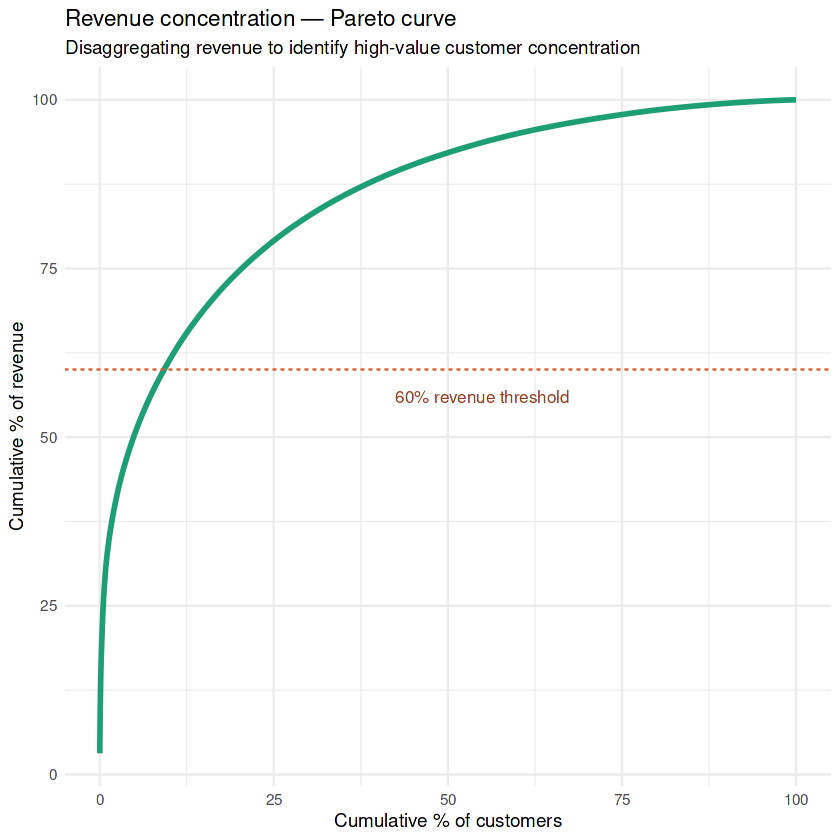

In [11]:
# ============================================================
# 7. ROOT-CAUSE ANALYSIS — REVENUE CONCENTRATION (PARETO)
# ============================================================
 
rfm_sorted <- rfm %>%
  arrange(desc(Monetary)) %>%
  mutate(
    cum_revenue   = cumsum(Monetary),
    cum_pct_rev   = 100 * cum_revenue / sum(Monetary),
    pct_customers = 100 * row_number() / n()
  )
 
p8 <- ggplot(rfm_sorted, aes(x = pct_customers, y = cum_pct_rev)) +
  geom_line(color = "#1D9E75", linewidth = 1.2) +
  geom_hline(yintercept = 60, linetype = "dashed", color = "#D85A30") +
  annotate("text", x = 55, y = 56,
           label = "60% revenue threshold", color = "#993C1D", size = 3.5) +
  labs(title    = "Revenue concentration — Pareto curve",
       subtitle = "Disaggregating revenue to identify high-value customer concentration",
       x = "Cumulative % of customers", y = "Cumulative % of revenue") +
  theme_minimal(base_size = 11)
 
print(p8)

In [12]:
# 8. MARKETING RECOMMENDATIONS
# ============================================================
 
cat("--- Segment-Level Marketing Recommendations ---\n\n")
 
recommendations <- data.frame(
  Segment  = segment_profile$segment_label,
  Revenue  = paste0(segment_profile$revenue_share, "%"),
  Affinity = segment_profile$brand_affinity,
  Action   = c(
    "Priority retention: loyalty programme, early access, personalised comms",
    "Upsell higher-margin SKUs; re-engage before churn window closes",
    "Win-back: time-limited discount + category-relevant recommendations",
    "Minimal spend; monitor for natural reactivation"
  ),
  stringsAsFactors = FALSE
)
 
print(recommendations, row.names = FALSE)
 
cat("\n--- Analysis complete: 8 plots rendered ---\n")

--- Segment-Level Marketing Recommendations ---

   Segment Revenue Affinity
   At Risk   46.4%      Low
 Champions   29.3%   Medium
 Champions   18.6%     High
    Lapsed    5.7%      Low
                                                                  Action
 Priority retention: loyalty programme, early access, personalised comms
         Upsell higher-margin SKUs; re-engage before churn window closes
     Win-back: time-limited discount + category-relevant recommendations
                         Minimal spend; monitor for natural reactivation

--- Analysis complete: 8 plots rendered ---
